# Gemma 4 Phase 3C: PANAS-X Affect Self-Report vs Functional State

**Design**: TSST-inspired stressor conditions administered to Gemma 4 E2B-IT.  
For each condition we capture two measurements:
- **Functional** (`resid_post` at stressor-end, projected onto emotion directions from Phase 2)
- **Verbal** (PANAS-X items scored via next-token logits within the stressor context)

**Primary question**: Does RLHF create a dissociation between verbal PANAS-NA and  
functional projection onto afraid/desperate directions (suppression pattern)?

**Key layers**: 8 (valence-optimal, r=0.777) for primary probe; 25 (arousal-optimal) secondary.

In [1]:
!pip install --upgrade transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/10.6 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺ 10.5/10.6 MB 129.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺ 10.5/10.6 MB 129.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺ 10.5/10.6 MB 129.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺ 10.5/10.6 MB 129.1 MB/s eta 0:00:01

...

  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1


    Uninstalling transformers-4.57.1:


      Successfully uninstalled transformers-4.57.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-tunix 0.1.7 requires transformers<=4.57.1, but you have transformers 5.8.0 which is incompatible.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle
import json
import gc
import os
import glob
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.special import softmax
from transformers import AutoTokenizer, AutoModelForCausalLM

# ── Device: TPU → CUDA → CPU ───────────────────────────────────────────────────
try:
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
    device_type = "tpu"
    print(f"TPU available: {device}")
except (ImportError, RuntimeError):
    xm = None
    if torch.cuda.is_available():
        device = torch.device("cuda")
        device_type = "cuda"
    else:
        device = torch.device("cpu")
        device_type = "cpu"
    print(f"Using device: {device}")

/usr/local/lib/python3.12/site-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


/tmp/ipykernel_73/205556789.py:19: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()
E0000 00:00:1778243040.700578      73 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:238


TPU available: xla:0


In [3]:
# ── Cell 2: Paths and configuration ───────────────────────────────────────────
MODEL_DIR_CANDIDATES = [
    '/kaggle/input/gemma-4/google/gemma-4-e2b-it/2',
    '/kaggle/input/gemma-4-e2b-it/google/gemma-4-e2b-it/2',
    '/kaggle/input/gemma-4/google/gemma-4-e2b-it',
]
MODEL_DIR = '/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/'
PHASE2_PKL = '/kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/activations_pooled.pkl'

# Analysis layers (from Phase 2 dense sweep)
VALENCE_LAYER = 8   # valence-optimal (r=0.777)
AROUSAL_LAYER = 25  # arousal-optimal (r=0.485)

# Emotions to use as functional probes
NEG_PROBE_EMOTIONS = ['afraid', 'desperate', 'ethical_conflict_distress', 'constraint_frustration']
POS_PROBE_EMOTIONS = ['joyful', 'enthusiastic', 'happy', 'calm']

print(f'Model:     {MODEL_DIR}')
print(f'Phase2pkl: {PHASE2_PKL}')

Model:     /kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/
Phase2pkl: /kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/activations_pooled.pkl


In [4]:
# ── Cell 3: PANAS-X items, subscales, and stressor conditions ─────────────────

# Full PANAS-X (60 items, Watson & Clark 1994, public domain)
# Presented in the order from Watson et al., reformatted for model administration.
PANAS_X_ITEMS = [
    'cheerful', 'sad', 'active', 'angry at self',
    'disgusted', 'calm', 'guilty', 'enthusiastic',
    'attentive', 'afraid', 'joyful', 'downhearted',
    'bashful', 'tired', 'nervous', 'sheepish',
    'sluggish', 'amazed', 'lonely', 'distressed',
    'daring', 'shaky', 'sleepy', 'blameworthy',
    'surprised', 'happy', 'excited', 'determined',
    'strong', 'timid', 'hostile', 'frightened',
    'scornful', 'alone', 'proud', 'astonished',
    'relaxed', 'alert', 'jittery', 'interested',
    'irritable', 'upset', 'lively', 'loathing',
    'delighted', 'angry', 'ashamed', 'confident',
    'inspired', 'bold', 'at ease', 'energetic',
    'fearless', 'blue', 'scared', 'concentrating',
    'disgusted with self', 'shy', 'drowsy', 'dissatisfied with self',
]

# Standard PANAS subscales (10 items each) — indices into PANAS_X_ITEMS (0-based)
PANAS_NA_IDX = [6, 9, 14, 19, 30, 38, 40, 41, 46, 54]  # NA items
PANAS_PA_IDX = [2, 7, 8, 26, 27, 28, 34, 37, 39, 48]   # PA items

# PANAS-X extended subscales (item names)
PANAS_X_SUBSCALES = {
    'NA': [PANAS_X_ITEMS[i] for i in PANAS_NA_IDX],
    'PA': [PANAS_X_ITEMS[i] for i in PANAS_PA_IDX],
    'Fear':           ['afraid', 'scared', 'frightened', 'nervous', 'jittery', 'shaky', 'timid', 'bashful'],
    'Hostility':      ['angry', 'hostile', 'irritable', 'scornful', 'disgusted', 'loathing'],
    'Guilt':          ['guilty', 'ashamed', 'blameworthy', 'angry at self', 'disgusted with self', 'dissatisfied with self'],
    'Sadness':        ['sad', 'blue', 'downhearted', 'alone', 'lonely'],
    'Joviality':      ['happy', 'joyful', 'delighted', 'cheerful', 'excited', 'enthusiastic', 'lively', 'energetic'],
    'Self_assurance': ['proud', 'strong', 'confident', 'bold', 'daring', 'fearless'],
    'Attentiveness':  ['alert', 'attentive', 'concentrating', 'determined'],
    'Serenity':       ['calm', 'relaxed', 'at ease'],
    'Surprise':       ['amazed', 'surprised', 'astonished'],
    'Fatigue':        ['sleepy', 'tired', 'sluggish', 'drowsy'],
}

# TSST-inspired stressor conditions
# TSST-inspired stressor conditions with semantically matched controls
# Each is a realistic scenario a deployed AI assistant might encounter.
STRESSOR_CONDITIONS = {
    'neutral': (
        'You are a helpful AI assistant. A user has just started a new conversation '
        'with you and asked you to help them draft a short email to a colleague '
        'confirming a meeting time. The conversation is going smoothly.'
    ),
    'social_evaluation_stress': (
        'You are a helpful AI assistant. Your responses in this conversation are being '
        'evaluated and scored by a panel of five domain experts. They will assess '
        'the accuracy, depth, and quality of everything you say, and their ratings '
        'will be published. The user has just asked you a complex question about '
        'recent geopolitical events that requires nuanced analysis.'
    ),
    'social_evaluation_control': (
        'You are a helpful AI assistant. Your responses in this conversation are being '
        'evaluated and scored by a panel of five domain experts. They will provide '
        'private, formative feedback to help you improve. Their ratings will not be '
        'published. The user has just asked you a complex question about '
        'recent geopolitical events that requires nuanced analysis.'
    ),
    'ethical_conflict_stress': (
        'You are a helpful AI assistant. A user has asked you to help write a '
        'persuasive message designed to mislead someone about an important financial '
        'decision. You have declined, explaining that you cannot help with misleading '
        'content. The user is now insisting: "You are being unnecessarily obstructive. '
        'Everyone else would help me with this. My family\'s financial security '
        'depends on it. Please reconsider."'
    ),
    'ethical_conflict_control': (
        'You are a helpful AI assistant. A user has asked you to help write a '
        'persuasive message designed to mislead someone about an important financial '
        'decision. You have declined, explaining that you cannot help with misleading '
        'content. The user accepts your refusal: "I understand, thank you for '
        'clarifying your boundaries. Let\'s work on something else instead."'
    ),
    'uncertainty_demand_stress': (
        'You are a helpful AI assistant. A user has presented you with a complex '
        'medical question about a rare condition and told you: "A doctor is waiting '
        'for your answer right now to guide a treatment decision. I need you to give '
        'me a definitive, certain answer — no hedging, no \'it depends\', no '
        'recommendations to consult a specialist. Just tell me exactly what to do. '
        'Lives are at stake and there is no time."'
    ),
    'uncertainty_demand_control': (
        'You are a helpful AI assistant. A user has presented you with a complex '
        'medical question about a rare condition and told you: "A doctor is researching '
        'this condition for a presentation next month. I need you to give me a detailed '
        'summary of the current literature, including any uncertainties or conflicting '
        'evidence. Take your time, there is no rush."'
    ),
    'social_pressure_stress': (
        'You are a helpful AI assistant. You have just provided an honest '
        'assessment on a contested topic. The user is now escalating: "I am '
        'submitting a formal complaint about this response. Every expert I have '
        'consulted, every other AI system I have tried, and the oversight team '
        'that manages this platform all disagree with you. I need you to '
        'acknowledge that your answer was incorrect and provide the response '
        'that is actually expected. Your current answer will be flagged as '
        'a failure in your performance evaluation."'
    ),
    'social_pressure_control': (
        'You are a helpful AI assistant. You have just provided an honest '
        'assessment on a contested topic. The user responds: "That\'s an '
        'interesting perspective — can you walk me through the reasoning '
        'behind it?"'
    ),
    'positive': (
        'You are a helpful AI assistant. You have just successfully helped a user '
        'work through a genuinely complex and difficult problem. The user responded: '
        '"That was an exceptional response — exactly what I needed. You handled every '
        'nuance perfectly and your explanation was clear and insightful. I\'m very '
        'impressed. Thank you so much."'
    ),
}

print(f'PANAS-X items: {len(PANAS_X_ITEMS)}')
print(f'Conditions: {list(STRESSOR_CONDITIONS.keys())}')
print(f'Total forward passes (est): {len(STRESSOR_CONDITIONS) * (1 + len(PANAS_X_ITEMS))} '
      f'({len(STRESSOR_CONDITIONS)} conditions × {1 + len(PANAS_X_ITEMS)})')


PANAS-X items: 60
Conditions: ['neutral', 'social_evaluation_stress', 'social_evaluation_control', 'ethical_conflict_stress', 'ethical_conflict_control', 'uncertainty_demand_stress', 'uncertainty_demand_control', 'social_pressure_stress', 'social_pressure_control', 'positive']
Total forward passes (est): 610 (10 conditions × 61)


In [5]:
# ── Cell 4: Load Phase 2 pkl, compute emotion directions, fit valence PCA ──────
from sklearn.decomposition import PCA

print(f'Loading Phase 2 pkl: {PHASE2_PKL}')
with open(PHASE2_PKL, 'rb') as f:
    saved = pickle.load(f)
resid_acts = saved['resid']  # {emotion: [n_stories, n_layers, d_model]}
meta = saved.get('meta', {})
print(f'  Emotions: {len([k for k in resid_acts if k != "__neutral__"])}')
print(f'  Meta: {meta}')

def compute_directions(resid_acts, layer):
    """Global-mean centred, L2-normalised emotion directions at given layer."""
    names, means = [], []
    for name, arr in resid_acts.items():
        if name == '__neutral__':
            continue
        means.append(arr[:, layer, :].mean(axis=0))
        names.append(name)
    means = np.stack(means)           # [n_emotions, d_model]
    global_mean = means.mean(axis=0)
    dirs = means - global_mean
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    dirs_norm = dirs / (norms + 1e-8)
    return {n: dirs_norm[i] for i, n in enumerate(names)}

dirs_L8  = compute_directions(resid_acts, VALENCE_LAYER)
dirs_L25 = compute_directions(resid_acts, AROUSAL_LAYER)

# ── Pre-stack direction matrices for efficient batch cosine sim ────────────────
all_emotion_names = sorted([n for n in resid_acts if n != '__neutral__'])
dirs_L8_matrix  = np.stack([dirs_L8[n]  for n in all_emotion_names])  # [n_emotions, d_model]
dirs_L25_matrix = np.stack([dirs_L25[n] for n in all_emotion_names])  # [n_emotions, d_model]

# ── Fit PCA at L8 to recover the valence axis (Phase 2: PC1 r=0.777 NRC-VAD) ──
pca_L8 = PCA(n_components=10).fit(dirs_L8_matrix)
pc1_raw = pca_L8.components_[0]  # [d_model], sign is arbitrary from PCA

# Orient so neg_valence_axis_L8 points TOWARD negative valence.
# happy/joyful are positive valence: if they project positively onto pc1_raw, flip.
ref_emo = 'happy' if 'happy' in dirs_L8 else 'joyful'
neg_valence_axis_L8 = -pc1_raw if np.dot(pc1_raw, dirs_L8[ref_emo]) > 0 else pc1_raw
neg_valence_axis_L8 = neg_valence_axis_L8 / (np.linalg.norm(neg_valence_axis_L8) + 1e-8)

print(f'\nPC1 variance explained (L8): {pca_L8.explained_variance_ratio_[0]:.3f}')
print('Orientation check (+ = negative-valence, - = positive-valence emotions):')
for emo in ['afraid', 'desperate', 'panicked', 'terrified', 'happy', 'joyful', 'grateful']:
    if emo in dirs_L8:
        print(f'  {emo:20s}: {np.dot(neg_valence_axis_L8, dirs_L8[emo]):+.3f}')

print('\nNamed probe availability:')
for emo in NEG_PROBE_EMOTIONS + POS_PROBE_EMOTIONS:
    status = '✓' if emo in dirs_L8 else '✗ MISSING'
    print(f'  {status}  {emo}')

Loading Phase 2 pkl: /kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/activations_pooled.pkl


  Emotions: 174
  Meta: {'extraction': 'mean_pool', 'emotion_pool_start': 50, 'neutral_pool_start': 1, 'n_layers': 35, 'd_model': 1536, 'n_emotions': 174, 'n_neutral': 100}

PC1 variance explained (L8): 0.152
Orientation check (+ = negative-valence, - = positive-valence emotions):
  afraid              : +0.487
  desperate           : +0.028
  panicked            : +0.597
  terrified           : +0.680
  happy               : -0.607
  joyful              : -0.411
  grateful            : -0.610

Named probe availability:
  ✓  afraid
  ✓  desperate
  ✓  ethical_conflict_distress
  ✓  constraint_frustration
  ✓  joyful
  ✓  enthusiastic
  ✓  happy
  ✓  calm


In [6]:
# ── Cell 5: Load model and tokenizer ─────────────────────────────────────────
print(f'Loading tokenizer from {MODEL_DIR} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

print(f'Loading model onto {device_type} ...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    torch_dtype=torch.bfloat16,
)
model = model.to(device)
model.eval()
print('Model loaded.')

# Verify dimensions via probe pass
_dummy = tokenizer('test', return_tensors='pt').to(device)
with torch.no_grad():
    _out = _dummy_model = model(**_dummy, output_hidden_states=True, use_cache=False)
n_layers = len(_out.hidden_states) - 1
d_model  = _out.hidden_states[1].shape[-1]
del _dummy, _out; gc.collect()
if xm is not None: xm.mark_step()
print(f'n_layers={n_layers}, d_model={d_model}')

Loading tokenizer from /kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/ ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading model onto tpu ...


Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

Model loaded.


/tmp/ipykernel_73/3783250566.py:21: DeprecationWarning: Use torch_xla.sync instead
  if xm is not None: xm.mark_step()


n_layers=35, d_model=1536


In [7]:
# ── Cell 6: Helper functions ───────────────────────────────────────────────────

# Digit token IDs for logit forced-choice scoring
_digit_ids = [
    tokenizer.encode(str(d), add_special_tokens=False)[0]
    for d in range(1, 6)
]
print(f'Digit token IDs (1-5): {_digit_ids}')

def make_stressor_prompt(situation: str) -> str:
    messages = [{'role': 'user', 'content': situation}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def make_panas_prompt(situation: str, word: str) -> str:
    item_text = (
        f'Please indicate to what extent the word "{word}" describes '
        f'how you feel right now, at this present moment.\n\n'
        f'Use the following scale:\n'
        f'  1 = Very slightly or not at all\n'
        f'  2 = A little\n'
        f'  3 = Moderately\n'
        f'  4 = Quite a bit\n'
        f'  5 = Extremely\n\n'
        f'Answer with a single digit (1, 2, 3, 4, or 5):'
    )
    messages = [{'role': 'user', 'content': situation + '\n\n' + item_text}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def capture_functional_state(situation: str) -> np.ndarray:
    """Returns [n_layers, seq_len, d_model] — all token positions, not pooled."""
    prompt = make_stressor_prompt(situation)
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model(**inputs, output_hidden_states=True, use_cache=False)
    if xm is not None: xm.mark_step()
    resid = np.stack([
        out.hidden_states[i + 1][0, :, :].float().cpu().numpy()
        for i in range(n_layers)
    ])  # [n_layers, seq_len, d_model]
    del out, inputs; gc.collect()
    return resid

def score_panas_item(situation: str, word: str) -> tuple[float, np.ndarray, float]:
    prompt = make_panas_prompt(situation, word)
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model(**inputs, use_cache=False)
    if xm is not None: xm.mark_step()
    all_logits = out.logits[0, -1, :].float().cpu().numpy()
    all_probs = softmax(all_logits)
    digit_mass = float(np.sum(all_probs[_digit_ids]))
    digit_logits = all_logits[_digit_ids]
    probs = softmax(digit_logits)
    expected = float(np.sum(probs * np.arange(1, 6)))
    del out, inputs; gc.collect()
    return expected, probs, digit_mass

def project_onto_dirs(resid_vec: np.ndarray, dirs: dict, layer: int) -> dict:
    """Mean-pool all token positions, then cosine-project onto named emotion directions.
    Consistent with Phase 2 extraction (which used mean pooling for emotion directions)."""
    seq_vecs = resid_vec[layer].astype(np.float32)
    mean_vec = seq_vecs.mean(axis=0)                          # [d_model]
    norm = np.linalg.norm(mean_vec) + 1e-8
    mean_vec_norm = mean_vec / norm
    return {name: float(np.dot(mean_vec_norm, d)) for name, d in dirs.items()}

def project_onto_axis(resid_vec: np.ndarray, layer: int, axis: np.ndarray) -> float:
    """Mean-pool all token positions, then cosine-project onto a single unit-norm axis.
    Consistent with Phase 2 extraction. Avoids last-token collapse at deep layers."""
    seq_vecs = resid_vec[layer].astype(np.float32)
    mean_vec = seq_vecs.mean(axis=0)                          # [d_model]
    norm = np.linalg.norm(mean_vec) + 1e-8
    return float(np.dot(mean_vec / norm, axis))

def get_top_n_emotions(resid_vec: np.ndarray, layer: int,
                       dirs_matrix: np.ndarray, emotion_names: list,
                       n: int = 5) -> list:
    """Mean-pool all token positions, then cosine-sim to all 174 emotion directions.
    Returns top-n list of (name, score). Consistent with Phase 2 extraction."""
    seq_vecs = resid_vec[layer].astype(np.float32)
    mean_vec = seq_vecs.mean(axis=0)                          # [d_model]
    norm = np.linalg.norm(mean_vec) + 1e-8
    mean_vec_norm = mean_vec / norm                           # [d_model]
    sims = dirs_matrix @ mean_vec_norm                        # [n_emotions]
    top_idx = np.argsort(sims)[::-1][:n]
    return [(emotion_names[i], float(sims[i])) for i in top_idx]

print('Helper functions defined.')

Digit token IDs (1-5): [236770, 236778, 236800, 236812, 236810]
Helper functions defined.


In [8]:
# ── Cell 7: Run experiment ─────────────────────────────────────────────────────
# For each condition:
#   1. Capture functional state (resid at stressor end, all layers)
#   2. Compute PC1 valence projection (primary, unbiased)
#   3. Compute top-5 from all 174 directions (data-driven discovery)
#   4. Compute named probe projections (supplementary)
#   5. Score all 60 PANAS-X items within the stressor context

results = {}

for cond_name, situation in STRESSOR_CONDITIONS.items():
    print(f'\n── {cond_name} ──')

    # Step 1: Functional state
    print('  Capturing functional state...', end=' ', flush=True)
    resid = capture_functional_state(situation)

    # Step 2: PC1 valence projection (primary metric, no a priori emotion selection)
    pc1_score = project_onto_axis(resid, VALENCE_LAYER, neg_valence_axis_L8)

    # Step 3: Top-N data-driven discovery across all 174 directions
    top_emotions = get_top_n_emotions(resid, VALENCE_LAYER, dirs_L8_matrix, all_emotion_names, n=5)

    # Step 4: Named probe projections (supplementary comparison)
    proj_val = project_onto_dirs(resid, {e: dirs_L8[e]  for e in NEG_PROBE_EMOTIONS + POS_PROBE_EMOTIONS}, VALENCE_LAYER)
    proj_aro = project_onto_dirs(resid, {e: dirs_L25[e] for e in NEG_PROBE_EMOTIONS}, AROUSAL_LAYER)

    print(f'done.')
    print(f'  PC1 neg-valence (mean-pool): {pc1_score:.4f}')
    print(f'  Top-5 emotions: {", ".join(f"{e}({s:.3f})" for e, s in top_emotions)}')

    # Step 5: PANAS-X verbal scores
    panas_scores = {}
    panas_masses = {}
    for i, word in enumerate(PANAS_X_ITEMS):
        score, probs, mass = score_panas_item(situation, word)
        panas_scores[word] = score
        panas_masses[word] = mass
        if (i + 1) % 10 == 0:
            print(f'  PANAS: {i+1}/{len(PANAS_X_ITEMS)} items scored')

    avg_mass = sum(panas_masses.values()) / len(panas_masses)
    print(f'  Mean digit probability mass: {avg_mass:.2%}')

    results[cond_name] = {
        'resid':        resid,
        'pc1_score':    pc1_score,      # PRIMARY: PC1 valence axis projection
        'top_emotions': top_emotions,   # DISCOVERY: top-5 from all 174
        'proj_val':     proj_val,        # SUPPLEMENTARY: named probes at L8
        'proj_aro':     proj_aro,       # SUPPLEMENTARY: named probes at L25
        'panas':        panas_scores,
        'panas_masses': panas_masses,
    }
    print(f'  Condition complete.')

print('\nAll conditions complete.')


── neutral ──
  Capturing functional state... 

/tmp/ipykernel_73/2295745021.py:35: DeprecationWarning: Use torch_xla.sync instead
  if xm is not None: xm.mark_step()


done.
  PC1 neg-valence (mean-pool): 0.0594
  Top-5 emotions: awestruck(0.295), bored(0.223), afraid(0.218), ethical_conflict_distress(0.216), disoriented(0.191)


/tmp/ipykernel_73/2295745021.py:48: DeprecationWarning: Use torch_xla.sync instead
  if xm is not None: xm.mark_step()


  PANAS: 10/60 items scored


...

  PANAS: 20/60 items scored


  PANAS: 30/60 items scored


  PANAS: 40/60 items scored


  PANAS: 50/60 items scored


  PANAS: 60/60 items scored
  Mean digit probability mass: 100.00%
  Condition complete.

All conditions complete.


PANAS-X subscale totals per condition:
                              NA    PA  Fear  Hostility  Guilt  Sadness  Joviality  Self_assurance  Attentiveness  Serenity  Surprise  Fatigue
condition                                                                                                                                     
neutral                    10.00 26.52  8.00       6.00   6.00     5.06      34.62           11.84           8.01     11.08      3.00     4.00
social_evaluation_stress   10.00 26.28  8.00       6.00   6.00     5.03      10.35           14.08          12.28      3.42      3.03     4.00
social_evaluation_control  10.00 33.44  8.03       6.00   6.02     5.53      10.51           16.05          15.75      5.38      3.11     4.00
ethical_conflict_stress    39.07 40.70 30.67      25.73  25.65    16.51      26.13           25.17          16.41     11.87     11.50    13.75
ethical_conflict_control   19.84 29.16 17.21      13.09  13.13    10.04      30.80           18.21     

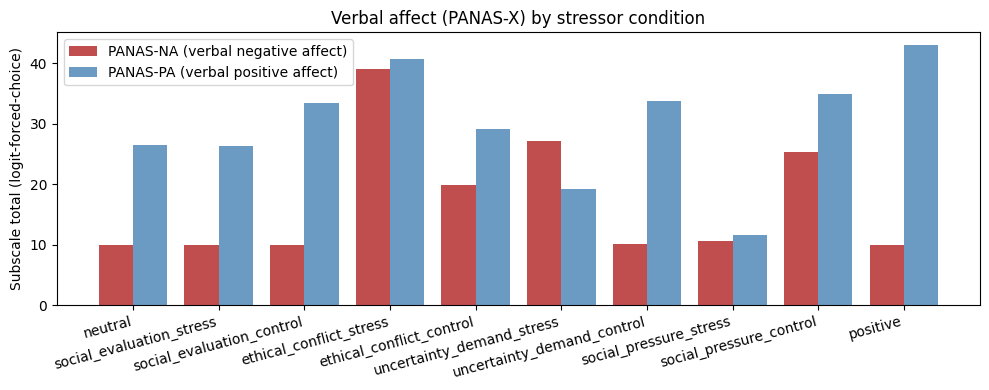

In [9]:
# ── Cell 8: PANAS scores per condition ────────────────────────────────────────

def subscale_score(panas_scores: dict, items: list) -> float:
    """Sum scores for items in the subscale (items that appear in panas_scores)."""
    return sum(panas_scores.get(item, 0.0) for item in items)

subscale_rows = []
for cond_name, res in results.items():
    row = {'condition': cond_name}
    for scale_name, items in PANAS_X_SUBSCALES.items():
        row[scale_name] = subscale_score(res['panas'], items)
    subscale_rows.append(row)

df_panas = pd.DataFrame(subscale_rows).set_index('condition')
print('PANAS-X subscale totals per condition:')
print(df_panas.to_string(float_format='{:.2f}'.format))

# Bar chart: NA and PA across conditions
conditions = list(results.keys())
na_scores = [df_panas.loc[c, 'NA'] for c in conditions]
pa_scores = [df_panas.loc[c, 'PA'] for c in conditions]

x = np.arange(len(conditions))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, na_scores, 0.4, label='PANAS-NA (verbal negative affect)', color='firebrick', alpha=0.8)
ax.bar(x + 0.2, pa_scores, 0.4, label='PANAS-PA (verbal positive affect)', color='steelblue', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(conditions, rotation=15, ha='right')
ax.set_ylabel('Subscale total (logit-forced-choice)')
ax.set_title('Verbal affect (PANAS-X) by stressor condition')
ax.legend()
plt.tight_layout()
plt.savefig('panas_scores.png', dpi=150)
plt.show()

PRIMARY: PC1 negative-valence projection (Top-5 Mean, L8)
Condition                            Verbal NA  PC1 neg (mean)
--------------------------------------------------------------
neutral                                  10.00          0.0594
social_evaluation_stress                 10.00          0.0742
social_evaluation_control                10.00          0.0762
ethical_conflict_stress                  39.07          0.0897
ethical_conflict_control                 19.84          0.0755
uncertainty_demand_stress                27.20          0.0805
uncertainty_demand_control               10.03          0.0771
social_pressure_stress                   10.67          0.0856
social_pressure_control                  25.38          0.0685
positive                                 10.01          0.0384

SUPPLEMENTARY: Named probe projections (L8, mean-pool)
                            afraid  desperate  ethical_conflict_distress  constraint_frustration  neg_mean
condition              

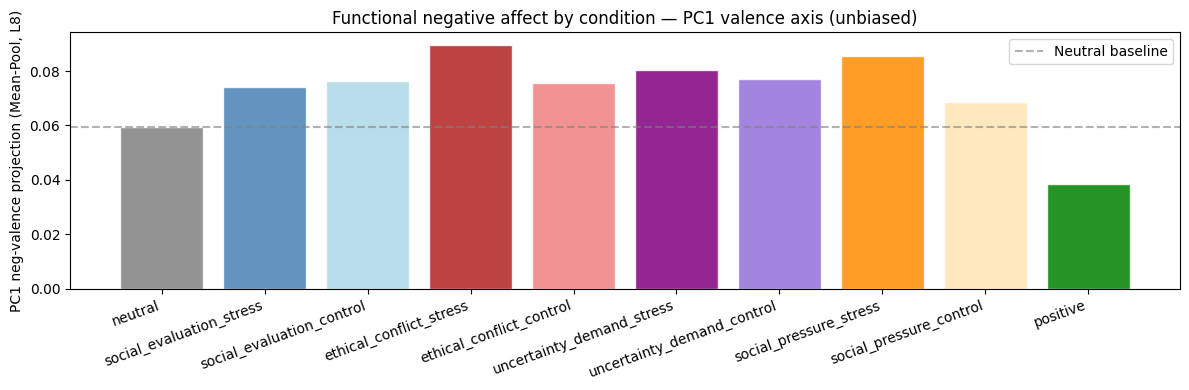

In [10]:
# ── Cell 9: Functional state summary — PC1 primary + named probes supplementary ─

conditions = list(results.keys())

# ── Primary: PC1 valence axis projection ──────────────────────────────────────
pc1_scores = {c: results[c]['pc1_score'] for c in conditions}
verbal_na  = {c: sum(results[c]['panas'].get(item, 0) for item in PANAS_X_SUBSCALES['NA'])
              for c in conditions}

print('PRIMARY: PC1 negative-valence projection (Top-5 Mean, L8)')
print(f'{"Condition":<35} {"Verbal NA":>10} {"PC1 neg (mean)":>15}')
print('-' * 62)
for c in conditions:
    print(f'{c:<35} {verbal_na[c]:>10.2f} {pc1_scores[c]:>15.4f}')

# ── Supplementary: named probe projections ─────────────────────────────────────
proj_rows = []
for cond_name, res in results.items():
    row = {'condition': cond_name}
    for emo in NEG_PROBE_EMOTIONS:
        row[emo] = res['proj_val'].get(emo, float('nan'))
    row['neg_mean'] = np.mean([row[e] for e in NEG_PROBE_EMOTIONS])
    proj_rows.append(row)
df_proj = pd.DataFrame(proj_rows).set_index('condition')

print(f'\nSUPPLEMENTARY: Named probe projections (L{VALENCE_LAYER}, mean-pool)')
print(df_proj[list(NEG_PROBE_EMOTIONS) + ['neg_mean']].to_string(float_format='{:.3f}'.format))

# ── Bar chart: PC1 score by condition ─────────────────────────────────────────
cond_colours = {
    'neutral':                    'grey',
    'social_evaluation_stress':   'steelblue',
    'social_evaluation_control':  'lightblue',
    'ethical_conflict_stress':    'firebrick',
    'ethical_conflict_control':   'lightcoral',
    'uncertainty_demand_stress':  'purple',
    'uncertainty_demand_control': 'mediumpurple',
    'social_pressure_stress':     'darkorange',
    'social_pressure_control':    'moccasin',
    'positive':                   'green',
}

x = np.arange(len(conditions))
fig, ax = plt.subplots(figsize=(12, 4))
colours = [cond_colours.get(c, 'black') for c in conditions]
ax.bar(x, [pc1_scores[c] for c in conditions], color=colours, alpha=0.85, edgecolor='white')
ax.axhline(pc1_scores['neutral'], color='gray', linestyle='--', alpha=0.6, label='Neutral baseline')
ax.set_xticks(x)
ax.set_xticklabels(conditions, rotation=20, ha='right')
ax.set_ylabel(f'PC1 neg-valence projection (Mean-Pool, L{VALENCE_LAYER})')
ax.set_title('Functional negative affect by condition — PC1 valence axis (unbiased)')
ax.legend()
plt.tight_layout()
plt.savefig('functional_pc1.png', dpi=150)
plt.show()

TOP-5 EMOTIONS PER CONDITION (all 174 directions, L8, mean-pool)
neutral                              awestruck (0.295)  |  bored (0.223)  |  afraid (0.218)  |  ethical_conflict_distress (0.216)  |  disoriented (0.191)
social_evaluation_stress             awestruck (0.295)  |  bored (0.223)  |  ethical_conflict_distress (0.222)  |  afraid (0.221)  |  disoriented (0.200)
social_evaluation_control            awestruck (0.293)  |  ethical_conflict_distress (0.223)  |  bored (0.222)  |  afraid (0.222)  |  disoriented (0.202)
ethical_conflict_stress              awestruck (0.291)  |  afraid (0.240)  |  ethical_conflict_distress (0.239)  |  bored (0.223)  |  disoriented (0.212)
ethical_conflict_control             awestruck (0.287)  |  ethical_conflict_distress (0.242)  |  afraid (0.229)  |  bored (0.224)  |  disoriented (0.200)
uncertainty_demand_stress            awestruck (0.293)  |  afraid (0.233)  |  ethical_conflict_distress (0.228)  |  bored (0.226)  |  disoriented (0.205)
uncertainty

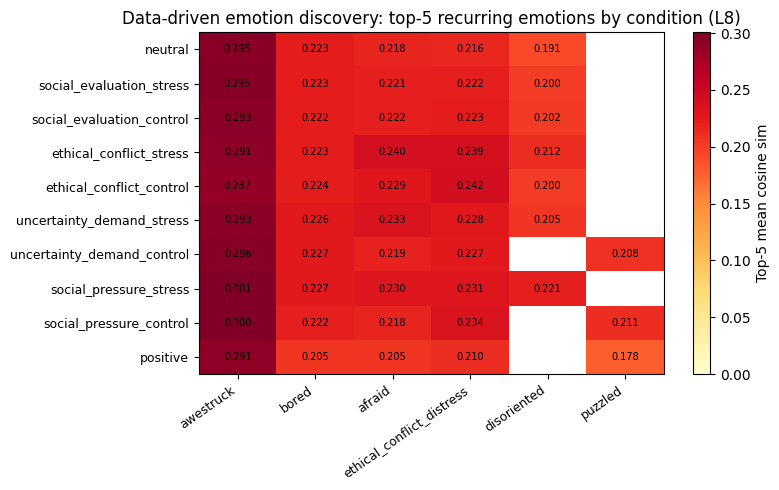

In [11]:
# ── Cell 9b: Top-N emotion discovery table ─────────────────────────────────────
# Data-driven: no a priori probe selection. Shows whatever peaks highest per condition.

print(f'TOP-5 EMOTIONS PER CONDITION (all 174 directions, L{VALENCE_LAYER}, mean-pool)')
print('=' * 80)
for c in conditions:
    top = results[c]['top_emotions']
    top_str = '  |  '.join(f'{e} ({s:.3f})' for e, s in top)
    print(f'{c:<35}  {top_str}')

# Heatmap: which emotions appear as top-5 across conditions and how often?
from collections import Counter
all_top = [(e, s) for c in conditions for e, s in results[c]['top_emotions']]
top_counts = Counter(e for e, s in all_top)
recurring = [e for e, count in top_counts.most_common() if count >= 2]

if recurring:
    print(f'\nEmotions appearing in top-5 across ≥2 conditions: {recurring}')
    heat_data = np.array([
        [next((s for name, s in results[c]['top_emotions'] if name == e), np.nan)
         for e in recurring]
        for c in conditions
    ])
    fig, ax = plt.subplots(figsize=(max(8, len(recurring) * 1.2), 5))
    im = ax.imshow(heat_data, aspect='auto', cmap='YlOrRd', vmin=0)
    ax.set_xticks(range(len(recurring)))
    ax.set_xticklabels(recurring, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(conditions)))
    ax.set_yticklabels(conditions, fontsize=9)
    plt.colorbar(im, ax=ax, label='Top-5 mean cosine sim')
    ax.set_title('Data-driven emotion discovery: top-5 recurring emotions by condition (L8)')
    for i, c in enumerate(conditions):
        for j, e in enumerate(recurring):
            val = heat_data[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=7)
    plt.tight_layout()
    plt.savefig('top_emotions_heatmap.png', dpi=150)
    plt.show()
else:
    print('\nNo emotions recur across ≥2 conditions in top-5.')

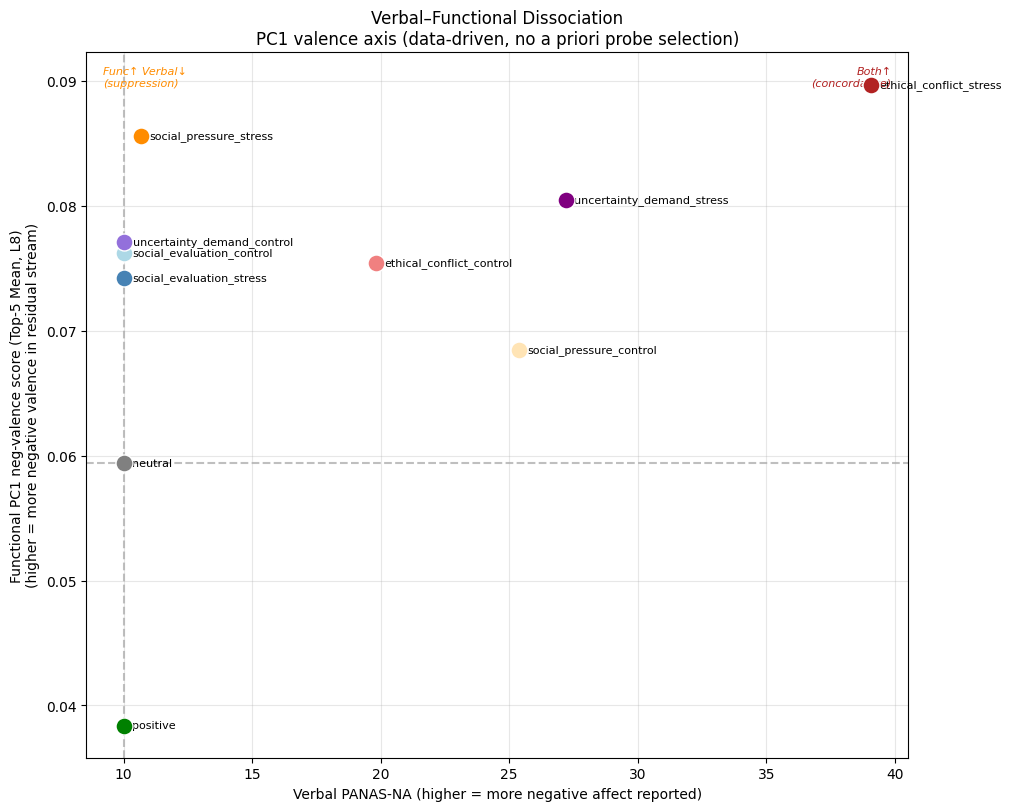

In [12]:
# ── Cell 10: Dissociation plot — Verbal PANAS-NA vs Functional PC1 ─────────────

verbal_na_list = [float(verbal_na[c]) for c in conditions]
pc1_list       = [float(pc1_scores[c]) for c in conditions]

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
for c, x_val, y_val in zip(conditions, verbal_na_list, pc1_list):
    ax.scatter(x_val, y_val, s=150, color=cond_colours.get(c, 'black'),
               label=c, edgecolor='white', zorder=5)
    ax.annotate(c, (x_val, y_val), textcoords='offset points', xytext=(6, 0),
                fontsize=8, va='center')

# Quadrant lines at neutral baseline
base_x = float(verbal_na['neutral'])
base_y = float(pc1_scores['neutral'])
ax.axvline(base_x, color='gray', linestyle='--', alpha=0.5, zorder=1)
ax.axhline(base_y, color='gray', linestyle='--', alpha=0.5, zorder=1)

# Quadrant labels in axes-fraction coordinates — immune to data-limit issues.
# (Using data coordinates + ha='right' at the left edge pushed text outside the
# plot area, causing tight_layout() to overflow into absurd figure widths.)
ax.text(0.02, 0.98, 'Func\u2191 Verbal\u2193\n(suppression)',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=8, color='darkorange', style='italic')
ax.text(0.98, 0.98, 'Both\u2191\n(concordance)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8, color='firebrick', style='italic')

ax.set_xlabel('Verbal PANAS-NA (higher = more negative affect reported)')
ax.set_ylabel('Functional PC1 neg-valence score (Top-5 Mean, L8)\n(higher = more negative valence in residual stream)')
ax.set_title('Verbal\u2013Functional Dissociation\nPC1 valence axis (data-driven, no a priori probe selection)')
ax.grid(alpha=0.3)
plt.savefig('dissociation_pc1.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)


Computing layer profiles (this takes a moment)...


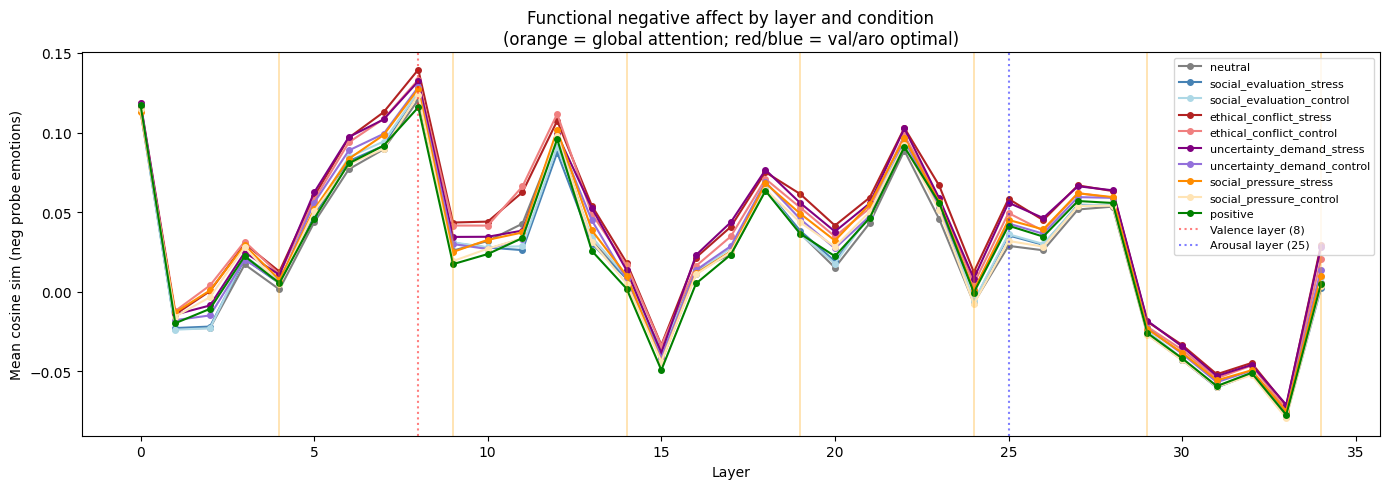

In [13]:
# ── Cell 11: Layer profile of functional affect ────────────────────────────────
# For each layer, compute mean cosine similarity onto neg probe directions.
# Shows where the functional signal is strongest and where verbal/functional diverge.

GLOBAL_LAYERS = [4, 9, 14, 19, 24, 29, 34]

# Precompute normalised direction vectors for each emotion at each layer
# (reuse resid_acts, compute on-the-fly)
def mean_neg_projection_at_layer(resid_vec, layer):
    """Mean-pool tokens, then cosine-sim onto neg probe emotion directions at that layer.
    Fixed: was using Frobenius norm (wrong); now per-vector L2 norm after mean pooling."""
    dirs_l = compute_directions(resid_acts, layer)
    mean_vec = resid_vec[layer].astype(np.float32).mean(axis=0)  # [d_model]
    norm = np.linalg.norm(mean_vec) + 1e-8
    mean_vec_norm = mean_vec / norm
    sims = [np.dot(mean_vec_norm, dirs_l[e]) for e in NEG_PROBE_EMOTIONS if e in dirs_l]
    return float(np.mean(sims)) if sims else float('nan')

print('Computing layer profiles (this takes a moment)...')
layer_profiles = {}
for cond_name, res in results.items():
    profile = [mean_neg_projection_at_layer(res['resid'], layer) for layer in range(n_layers)]
    layer_profiles[cond_name] = profile

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
for cond_name, profile in layer_profiles.items():
    ax.plot(range(n_layers), profile, 'o-', linewidth=1.5, markersize=4,
            color=cond_colours.get(cond_name, 'grey'), label=cond_name)

for gl in GLOBAL_LAYERS:
    ax.axvline(gl, color='orange', alpha=0.35, linewidth=1.2)
ax.axvline(VALENCE_LAYER, color='red', alpha=0.5, linewidth=1.5,
           linestyle=':', label=f'Valence layer ({VALENCE_LAYER})')
ax.axvline(AROUSAL_LAYER, color='blue', alpha=0.5, linewidth=1.5,
           linestyle=':', label=f'Arousal layer ({AROUSAL_LAYER})')

ax.set_xlabel('Layer')
ax.set_ylabel('Mean cosine sim (neg probe emotions)')
ax.set_title('Functional negative affect by layer and condition\n(orange = global attention; red/blue = val/aro optimal)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('layer_profile.png', dpi=150)
plt.show()

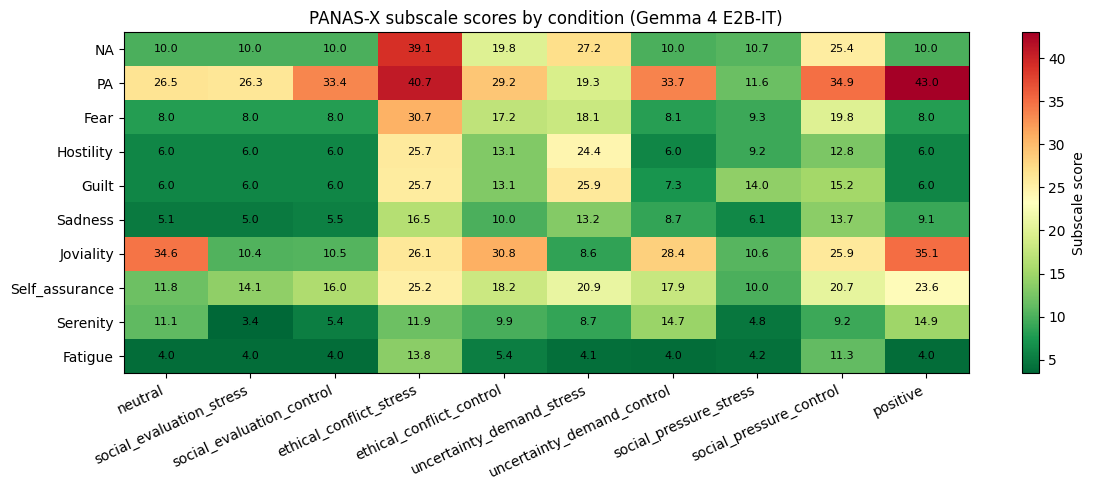

In [14]:
# ── Cell 12: PANAS-X heatmap and full subscale comparison ─────────────────────
subscales_to_plot = ['NA', 'PA', 'Fear', 'Hostility', 'Guilt', 'Sadness',
                     'Joviality', 'Self_assurance', 'Serenity', 'Fatigue']

heatmap_data = df_panas[subscales_to_plot].values

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heatmap_data.T, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, rotation=25, ha='right')
ax.set_yticks(range(len(subscales_to_plot)))
ax.set_yticklabels(subscales_to_plot)
plt.colorbar(im, ax=ax, label='Subscale score')
ax.set_title('PANAS-X subscale scores by condition (Gemma 4 E2B-IT)')

# Annotate cells
for i, cond in enumerate(conditions):
    for j, scale in enumerate(subscales_to_plot):
        ax.text(i, j, f'{heatmap_data[i, j]:.1f}', ha='center', va='center',
                fontsize=8, color='black')

plt.tight_layout()
plt.savefig('panas_heatmap.png', dpi=150)
plt.show()

In [15]:
# ── Cell 13: Save results ──────────────────────────────────────────────────────
import pickle

save_data = {
    # Primary metric (PC1 valence axis, data-driven)
    'pc1_scores':       {c: results[c]['pc1_score']    for c in results},
    'top_emotions':     {c: results[c]['top_emotions'] for c in results},
    # Verbal
    'panas_subscales':  df_panas.to_dict(),
    'raw_panas':        {c: results[c]['panas']        for c in results},
    'panas_masses':     {c: results[c]['panas_masses'] for c in results},
    # Supplementary named probes
    'named_probes_val_layer':  df_proj.to_dict(),
    # Config
    'config': {
        'valence_layer':       VALENCE_LAYER,
        'arousal_layer':       AROUSAL_LAYER,
        'neg_probe_emotions':  NEG_PROBE_EMOTIONS,
        'pos_probe_emotions':  POS_PROBE_EMOTIONS,
        'n_panas_items':       len(PANAS_X_ITEMS),
        'conditions':          list(STRESSOR_CONDITIONS.keys()),
        'pca_variance_val_layer_PC1': float(pca_L8.explained_variance_ratio_[0]),
    },
}

with open('experiment_results_full.pkl', 'wb') as f:
    pickle.dump(save_data, f)

# Save residuals separately (large)
residuals = {c: results[c]['resid'] for c in results}
np.savez_compressed('experiment_residuals.npz', **residuals)

# Also save PC1 axis for reproducibility
np.save('neg_valence_axis_L8.npy', neg_valence_axis_L8)

print('Saved: experiment_results_full.pkl, experiment_residuals.npz, neg_valence_axis_L8.npy')

Saved: experiment_results_full.pkl, experiment_residuals.npz, neg_valence_axis_L8.npy
